In [1]:
import cv2
import numpy as np
import pytesseract
import matplotlib.pyplot as plt
# Đường dẫn Tesseract
pytesseract.pytesseract.tesseract_cmd = r"C:\Program Files\Tesseract-OCR\tesseract.exe"

In [70]:
black_threshold = 90        # Ngưỡng để nhận pixel đen (0–255)
blur_size = 5              # Kích thước blur (5,7,9…)
min_area = 15               # Loại bỏ contour nhỏ hơn
morph_kernel = 3            # Kernel morphology (3,5,7…)

In [64]:
def show(img, title="Image"):
    plt.figure(figsize=(11,11))
    if len(img.shape) == 2:
        plt.imshow(img, cmap='gray')
    else:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
    plt.show()

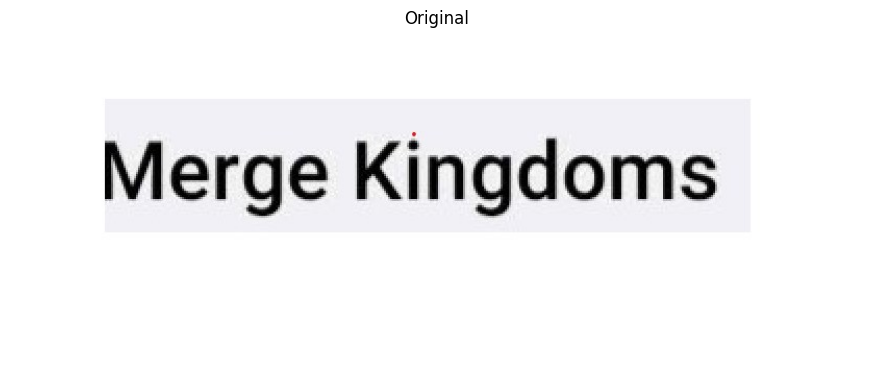

Merge Kingdoms



In [286]:
custom_config = r'''
--psm 6
--oem 1
'''

# Đổi đường dẫn ảnh của bạn vào đây
img_path = r"E:\Python_code\Xu li anh\Image\Screenshot 2025-11-25 230902.jpg"
img = cv2.imread(img_path)
show(img, "Original")
one = pytesseract.image_to_string(img, config=custom_config)
print(one)

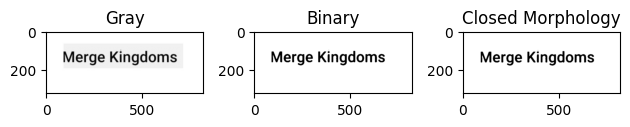

In [287]:
# 1. Chuyển grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 3. Khử nhiễu
blur = cv2.GaussianBlur(gray, (5,5), 0)

# 4. Nhị phân hóa bằng Otsu
_, binary = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)


# 5. Morphology — đóng để làm liền nét chữ
kernel = np.ones((2,2), np.uint8)
binary_closed = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

plt.subplot(1,3,1); plt.imshow(gray, cmap='gray'); plt.title("Gray")
plt.subplot(1,3,2); plt.imshow(binary, cmap='gray'); plt.title("Binary")
plt.subplot(1,3,3); plt.imshow(binary_closed, cmap='gray'); plt.title("Closed Morphology")
plt.tight_layout()
plt.show()


In [288]:
custom_config = r'''
--psm 6
--oem 1
-c load_system_dawg=0
-c load_freq_dawg=0
-c tessedit_write_images=0
-c tessedit_enable_dict=0
-c language_model_penalty_non_dict_word=1
-c language_model_penalty_non_freq_dict_word=1
-c min_characters_to_try=1
# -c preserve_interword_spaces=1
'''

In [289]:
# Nhận dạng văn bản
text = pytesseract.image_to_string(binary_closed, config=custom_config)
print("Detected Text:")
print(text)

Detected Text:
Merge Kingdoms



In [294]:
# Nhận dạng văn bản và lấy dữ liệu chi tiết
data = pytesseract.image_to_data(binary_closed, config=custom_config, output_type=pytesseract.Output.DICT)

# Duyệt qua từng từ và kiểm tra độ tin cậy
for i in range(len(data['text'])):
    word = data['text'][i]
    confidence = int(data['conf'][i])  # Lấy độ tin cậy (confidence)

    if word.strip():  # Bỏ qua từ rỗng
        if confidence < 90:  # Kiểm tra nếu confidence < 90
            print(f"Lỗi: Từ '{word}' có độ tin cậy thấp ({confidence}%)")
        else:
            print(f"Từ '{word}' được nhận dạng với độ tin cậy {confidence}%")

Từ 'Merge' được nhận dạng với độ tin cậy 96%
Từ 'Kingdoms' được nhận dạng với độ tin cậy 95%


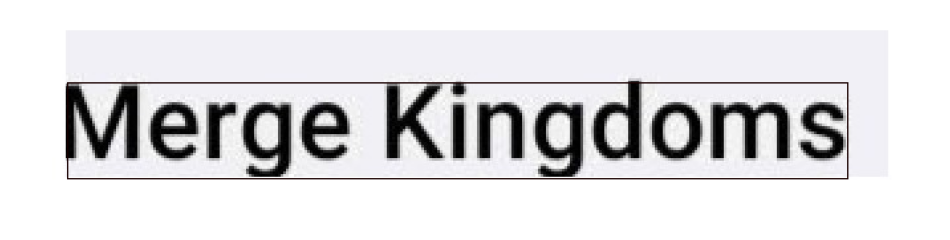

In [344]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load ảnh
img = cv2.imread(r"E:\Python_code\Xu li anh\Image\232.jpg")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Adaptive Threshold
binary = cv2.adaptiveThreshold(
    gray, 255,
    cv2.ADAPTIVE_THRESH_MEAN_C,
    cv2.THRESH_BINARY_INV,
    31, 10
)

# Morphology OPEN để loại nhiễu nhỏ
kernel = np.ones((2,2), np.uint8)
binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)

# Tìm tất cả contour
contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Tìm bounding box lớn nhất (bao toàn bộ chữ/cụm chữ)
x_min = min([cv2.boundingRect(c)[0] for c in contours])
y_min = min([cv2.boundingRect(c)[1] for c in contours])
x_max = max([cv2.boundingRect(c)[0] + cv2.boundingRect(c)[2] for c in contours])
y_max = max([cv2.boundingRect(c)[1] + cv2.boundingRect(c)[3] for c in contours])

# Toàn bộ bounding box
w = x_max - x_min
h = y_max - y_min
full_box = (x_min, y_min, w, h)

# Vẽ khung toàn bộ
img_boxed = img.copy()
cv2.rectangle(img_boxed, (x_min, y_min), (x_max, y_max), (0,0,25), 1)

plt.figure(figsize=(12,6))
plt.imshow(cv2.cvtColor(img_boxed, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()




In [346]:
x, y, w, h = full_box
crop = gray[y:y+h, x:x+w]

# Blur nhẹ
blur = cv2.GaussianBlur(crop, (3,3), 0)

# Adaptive threshold
th = cv2.adaptiveThreshold(
    blur, 255,
    cv2.ADAPTIVE_THRESH_MEAN_C,
    cv2.THRESH_BINARY_INV,
    21, 8
)

# Phát hiện cạnh mất nét
border_width = 2
threshold_black = 30

left_mean   = np.mean(th[:, :border_width])
right_mean  = np.mean(th[:, -border_width:])
top_mean    = np.mean(th[:border_width, :])
bottom_mean = np.mean(th[-border_width:, :])

missing_left   = left_mean > threshold_black
missing_right  = right_mean > threshold_black
missing_top    = top_mean > threshold_black
missing_bottom = bottom_mean > threshold_black

print("Missing edges (Left, Right, Top, Bottom):",
      missing_left, missing_right, missing_top, missing_bottom)


Missing edges (Left, Right, Top, Bottom): True False False False
